# Project 2 - Spam/Ham Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)
import joblib

In [2]:
data_dir = "/content/drive/MyDrive/InternWeek2Project2_Spam_Analysis/spam.csv"



In [3]:
data = pd.read_csv(data_dir, encoding='latin-1')

Drop unnnamed columns

In [4]:
data = data[['v1', 'v2']]
data.columns = ['label', 'message']

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
print(data.shape)
print(data.head())
print("\nClass distribution:")
print(data['label'].value_counts())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


/tmp/ipykernel_1350/4007711267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='label', palette=['steelblue'])
/tmp/ipykernel_1350/4007711267.py:2: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=data, x='label', palette=['steelblue'])


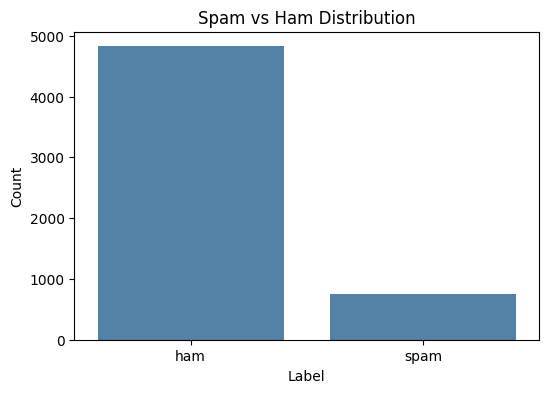

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='label', palette=['steelblue'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

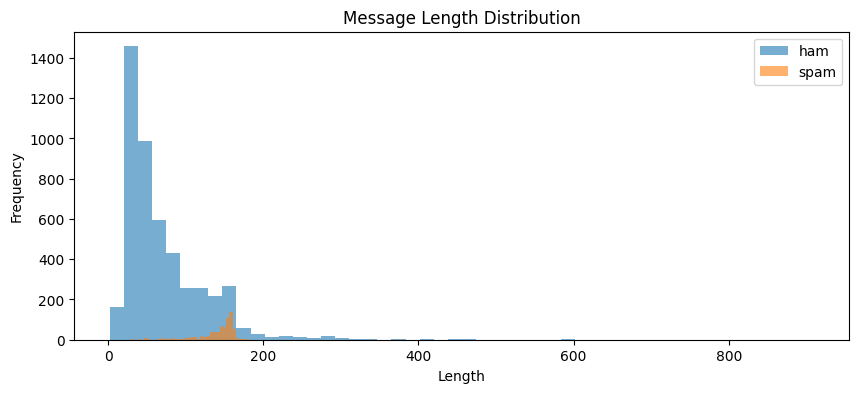

In [9]:
data['msg_length'] = data['message'].apply(len)

plt.figure(figsize=(10, 4))
data.groupby('label')['msg_length'].plot(kind='hist', bins=50, alpha=0.6, legend=True)
plt.title('Message Length Distribution')
plt.xlabel('Length')
plt.show()

Text preprocessing

In [10]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = text.strip()
    return text

data['clean_message'] = data['message'].apply(preprocess_text)

print(data[['message', 'clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in  a wkly comp to win fa cup final...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


Encode the labels

In [11]:
data['label_encoded'] = data['label'].map({'ham': 0, 'spam': 1})

X = data['clean_message']
y = data['label_encoded']

Split the data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4457,), Test: (1115,)


Vectorize with CountVectorizer

In [13]:
count_vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count  = count_vectorizer.transform(X_test)

print("CountVectorizer shape:", X_train_count.shape)

CountVectorizer shape: (4457, 5000)


Vectorize with TF-IDF

In [14]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (4457, 5000)


Train Naive Bayes (CountVectorizer)

In [15]:
nb_count = MultinomialNB()
nb_count.fit(X_train_count, y_train)
y_pred_nb_count = nb_count.predict(X_test_count)

print("=== Naive Bayes + CountVectorizer ===")
print(classification_report(y_test, y_pred_nb_count, target_names=['Ham', 'Spam']))

=== Naive Bayes + CountVectorizer ===
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.94      0.90      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



Train Naive Bayes (TF-IDF)

In [16]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("=== Naive Bayes + TF-IDF ===")
print(classification_report(y_test, y_pred_nb_tfidf, target_names=['Ham', 'Spam']))

=== Naive Bayes + TF-IDF ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



Train Logistic Regression (TF-IDF)

In [17]:
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("=== Logistic Regression + TF-IDF ===")
print(classification_report(y_test, y_pred_lr_tfidf, target_names=['Ham', 'Spam']))

=== Logistic Regression + TF-IDF ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



Compare all models

               Model  Accuracy  Precision   Recall  F1 Score
NB + CountVectorizer  0.979372   0.943662 0.899329  0.920962
         NB + TF-IDF  0.965919   0.991150 0.751678  0.854962
         LR + TF-IDF  0.963229   0.990909 0.731544  0.841699


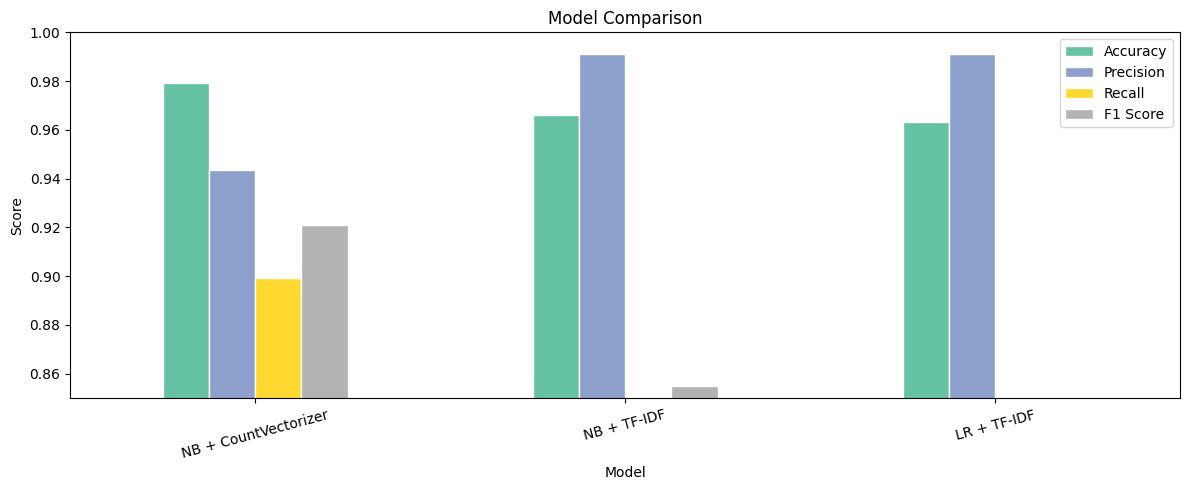

In [18]:
models = {
    'NB + CountVectorizer' : y_pred_nb_count,
    'NB + TF-IDF'          : y_pred_nb_tfidf,
    'LR + TF-IDF'          : y_pred_lr_tfidf
}

results = []
for name, preds in models.items():
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'F1 Score' : f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white'
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

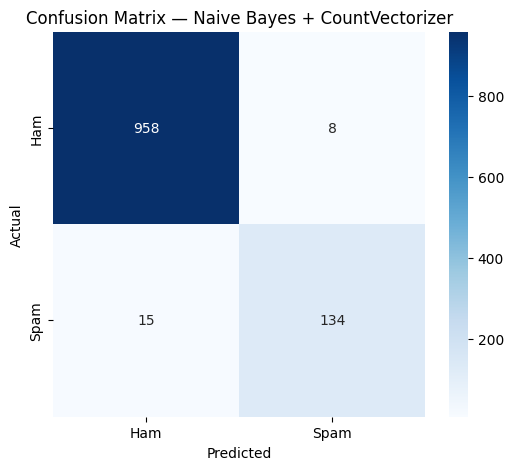

In [19]:
cm = confusion_matrix(y_test, y_pred_nb_count)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix — Naive Bayes + CountVectorizer')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Best Model

In [20]:
joblib.dump(count_vectorizer, 'spam_vectorizer.pkl')
joblib.dump(nb_count,         'spam_model.pkl')

print("Best Model : Naive Bayes + CountVectorizer")
print(f"Accuracy  : 0.9794")
print(f"Precision : 0.9437")
print(f"Recall    : 0.8993")
print(f"F1 Score  : 0.9209")
print("Vectorizer and model saved.")

Best Model : Naive Bayes + CountVectorizer
Accuracy  : 0.9794
Precision : 0.9437
Recall    : 0.8993
F1 Score  : 0.9209
Vectorizer and model saved.


In [21]:
from google.colab import files

loaded_vectorizer = joblib.load('spam_vectorizer.pkl')
loaded_model      = joblib.load('spam_model.pkl')

# Testing with new messages
test_messages = [
    "Congratulations! You've won a free prize. Call now to claim!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Click here immediately.",
    "Can you send me the notes from today's class?"
]

cleaned     = [preprocess_text(m) for m in test_messages]
vectorized  = loaded_vectorizer.transform(cleaned)
predictions = loaded_model.predict(vectorized)
labels      = ['Spam' if p == 1 else 'Ham' for p in predictions]

for msg, label in zip(test_messages, labels):
    print(f"[{label}] {msg}")

files.download('spam_vectorizer.pkl')
files.download('spam_model.pkl')

[Spam] Congratulations! You've won a free prize. Call now to claim!
[Ham] Hey, are we still meeting for lunch tomorrow?
[Spam] URGENT: Your account has been compromised. Click here immediately.
[Ham] Can you send me the notes from today's class?


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>